In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11
})

from utils import phase_velocity_vti
from squirt_flow import squirt_flow_drained,squirt_flow_undrained
from EMT import hudson,dem

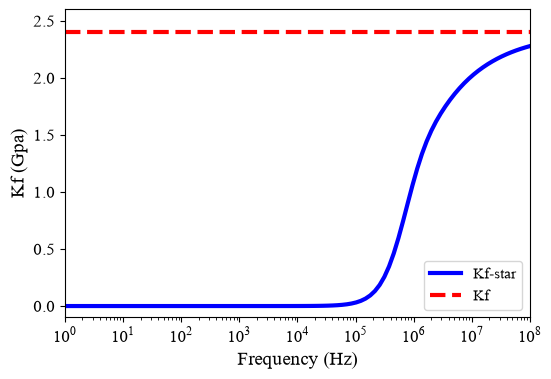

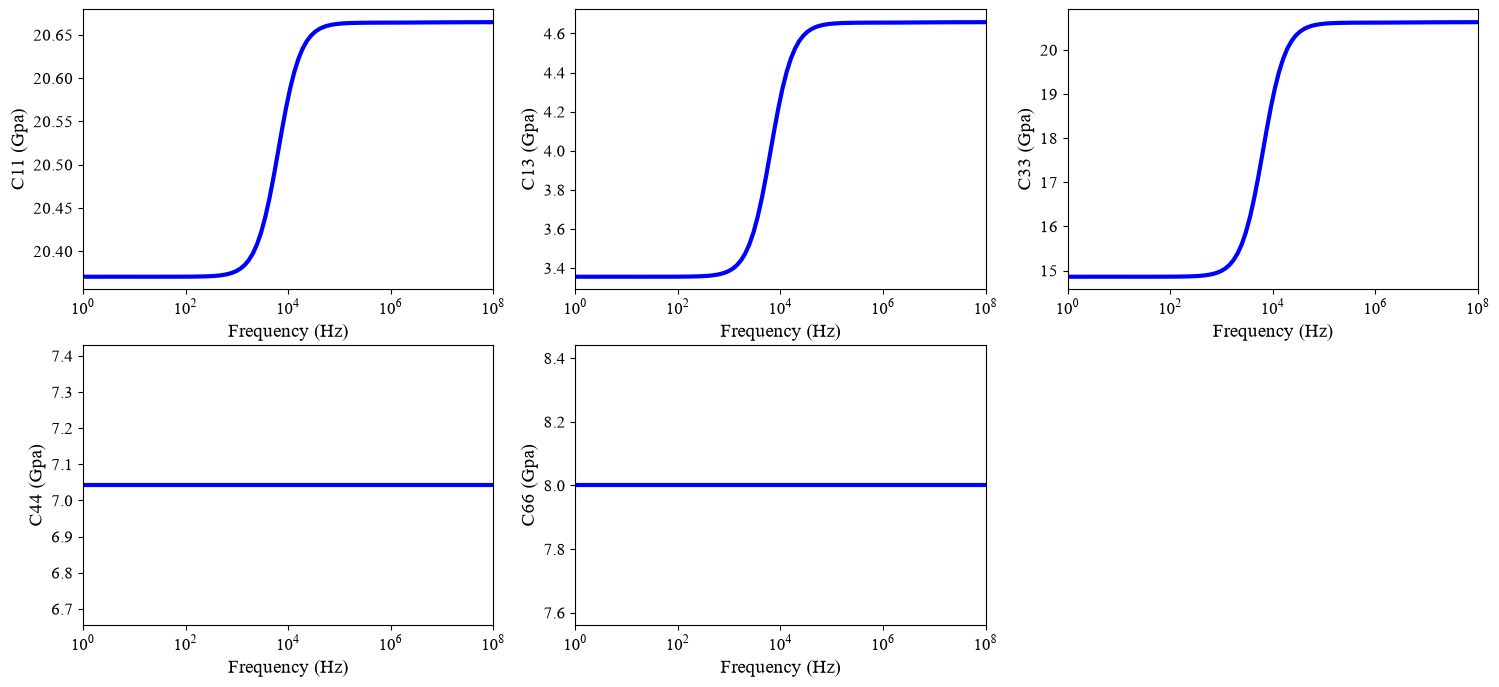

In [22]:
Km    = 10e9
Gm    = 8e9
rhos  = 2.65e3 
Kf    = 2.4e9
Gf    = 0
vis   = 1e-3
h0    = 1e-7
asp   = 0.001
rb    = h0/(2*asp)
f     = np.logspace(0,8,100)
epsilon = 0.05

Kf_star = squirt_flow_drained(Kf,vis,h0,rb,f)

C1_aniso = np.zeros((5,len(f)),dtype=np.complex128) 
C11      = np.zeros(len(f),dtype=np.complex128) 
C13      = np.zeros(len(f),dtype=np.complex128) 
C33      = np.zeros(len(f),dtype=np.complex128) 
C44      = np.zeros(len(f),dtype=np.complex128) 
C66      = np.zeros(len(f),dtype=np.complex128) 
for i in range(len(f)):
    C1_aniso[:,i] = hudson(Km,Gm,Kf_star[i],Gf,asp,epsilon)[0]
    C11[i] = C1_aniso[0,i]
    C13[i] = C1_aniso[1,i]
    C33[i] = C1_aniso[2,i]
    C44[i] = C1_aniso[3,i]
    C66[i] = C1_aniso[4,i]

plt.figure(figsize=(6,4))
plt.semilogx(f,np.real(Kf_star)/1e9,
             label='Kf-star',color='blue',linewidth=3)
plt.semilogx([f.min(),f.max()],[Kf/1e9,Kf/1e9],
             label='Kf',color='red',linestyle='--',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Kf (Gpa)')
plt.xlim(f.min(),f.max())
plt.ylim(-0.1,2.6)
plt.legend()

plt.figure(figsize=(18,8))
plt.subplot(2,3,1)
plt.semilogx(f,np.real(C11)/1e9,
             label='C11',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C11 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,2)
plt.semilogx(f,np.real(C13)/1e9,
             label='C13',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C13 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,3)
plt.semilogx(f,np.real(C33)/1e9,
             label='C33',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C33 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,4)
plt.semilogx(f,np.real(C44)/1e9,
             label='C44',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C44 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,5)
plt.semilogx(f,np.real(C66)/1e9,
             label='C66',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C66 (Gpa)')
plt.xlim(f.min(),f.max())

plt.show()